# Modelagem do Risco Não Linear de Inadimplência de Crédito com Splines de Regressão

## Resumo Executivo

A equipe de risco de um banco de varejo precisa saber *onde* o risco de inadimplência se torna não linear antes de se comprometer com um scorecard de produção. Em vez de discretizar (binning) manualmente cada característica, a equipe ajusta um **modelo aditivo generalizado** com `PROC GAM`: cada característica do tomador entra como uma spline de suavização cúbica, de modo que relações de limiar (threshold) e em forma de U são estimadas diretamente a partir dos dados na escala logit. Em uma carteira sintética deliberadamente adversa de 100 empréstimos (39% de inadimplência), o modelo aditivo com splines reduz a deviância de 133,75 (apenas intercepto) para 61,69 — uma queda de 72,06 — resultando em um AIC do modelo de 81,69. A spline ajustada da relação dívida-renda carrega o maior coeficiente (4,34), e a discretização do desfecho bruto confirma a estrutura projetada: o risco de inadimplência é fortemente em **forma de U em relação à idade** (66,7% entre os tomadores mais jovens, 4,8% na meia-idade, 86,4% entre os mais velhos) e cresce à medida que a alavancagem aumenta.

## Fontes de Dados

| Conjunto de dados | Linhas | Papel | Variáveis-chave | Descrição |
|---------|------|------|---------------|-------------|
| `loans` | 100 | Entrada da modelagem | `default` (alvo 0/1), `age`, `dti` (dívida-renda), `utilization` (uso de crédito rotativo) | Solicitações sintéticas de empréstimo de varejo. O verdadeiro log-odds de inadimplência é construído com não linearidades deliberadas — um efeito de idade em forma de U e dobras (hinges) de limiar em dívida-renda e utilização — e então amostrado por Bernoulli. Gerado inline com `call streaminit(20260531)` e `rand()`; sem arquivos externos. |

Este ambiente é executado sem licença, portanto a saída é limitada a 100 observações. O cenário é dimensionado para esse limite: o sinal é feito forte o suficiente para que um modelo aditivo com splines de três termos possa recuperar as formas a partir de 100 empréstimos.

# Por que usar splines para risco de crédito

Scorecards tradicionais se apoiam em regressão logística com variáveis discretizadas manualmente (weight-of-evidence / information-value). Isso funciona, mas obriga o analista a *adivinhar* onde estão os limiares de risco e a curvatura. Um **modelo aditivo generalizado (GAM)** substitui cada termo linear por uma função suave — aqui uma spline de suavização cúbica com três graus de liberdade — de modo que a forma da curva é estimada e não assumida. O `PROC GAM` ajusta essas suavizações na escala logit para um alvo binário, exatamente o cenário de um modelo de probabilidade de inadimplência.

Neste notebook, assumimos o papel da equipe de risco de um banco de varejo. Nós:

1. Geramos uma carteira de empréstimos sintética cuja probabilidade **verdadeira** de inadimplência é genuinamente não linear (um efeito de idade em forma de U e efeitos de limiar em dívida-renda e utilização).
2. Ajustamos um modelo aditivo binomial/logit com splines e lemos sua deviância, AIC e coeficientes por suavização.
3. Confirmamos as formas recuperadas discretizando o desfecho bruto de inadimplência e plotando-o com o `PROC SGPLOT`.

Nada aqui requer dados externos ou conexão de rede.

## Passo 1 - Construir uma carteira de empréstimos sintética

Simulamos 100 solicitações de empréstimo. Cada tomador tem três características. O **log-odds de inadimplência** é construído a partir de componentes intencionalmente não lineares, de modo que temos uma verdade de referência conhecida para o modelo de splines recuperar:

- **Idade** - uma forma de U: o risco de inadimplência é elevado para tomadores muito jovens e muito velhos e mais baixo na meia-idade. Codificamos isso como um termo de idade centrado e ao quadrado.
- **DTI** - um efeito de limiar: pouco impacto até que a relação dívida-renda ultrapasse ~0,35, então o risco cresce (uma dobra/hinge unilateral).
- **Utilização** - uma segunda dobra em ~0,60 do limite de crédito rotativo.

A variável binária `default` é então extraída de uma distribuição de Bernoulli com essa probabilidade. O intercepto é definido baixo o suficiente para que as não linearidades projetadas, e não um patamar base elevado, conduzam as inadimplências — esta é uma carteira deliberadamente adversa e de alto risco, escolhida para que as formas sejam visíveis em apenas 100 empréstimos.

In [1]:
DADOS loans;
   CHAMAR streaminit(20260531);

   FAZER id = 1 ATÉ 100;
      /* ---- características do tomador ---- */
      AGE         = 18 + 52 * rand("UNIFORM");     /* 18 .. 70 anos   */
      dti         = 0.05 + 0.55 * rand("UNIFORM"); /* dívida-renda    */
      utilization = rand("UNIFORM");               /* 0 .. 1 do limite */

      /* ---- log-odds VERDADEIRO não linear de inadimplência ---- */
      age_c    = (AGE - 44) / 12;
      eta_age  = 1.6 * age_c * age_c;              /* forma de U      */
      eta_dti  = 8.0 * MAX(dti - 0.35, 0);         /* dobra de limiar */
      eta_util = 2.5 * MAX(utilization - 0.60, 0); /* dobra de limiar */

      eta = -3.2 + eta_age + eta_dti + eta_util;

      p_true  = LOGISTIC(eta);
      default = rand("BERNOULLI", p_true);

      REMOVER age_c eta_age eta_dti eta_util eta p_true;
      SAÍDA;
   FIM;
EXECUTAR;

PROCEDIMENTO MÉDIAS DADOS=loans n mean MIN MAX maxdec=3;
   VARIÁVEL default AGE dti utilization;
   RÓTULO default="Inadimplência" AGE="Idade"
         dti="Dívida-Renda" utilization="Utilização";
EXECUTAR;

                                                  The MEANS Procedure

 Variable     Label                  N           Mean     Minimum     Maximum
 ----------------------------------------------------------------------------
 default      Inadimplência        100          0.390       0.000       1.000
 AGE          Idade                100         44.993      18.342      69.646
 dti          Dívida-Renda         100          0.312       0.059       0.590
 utilization  Utilização           100          0.548       0.012       0.988
 ----------------------------------------------------------------------------




NOTE: DATA loans


NOTE: Wrote loans (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


O resumo do `PROC MEANS` confirma a carteira: uma taxa geral de inadimplência de **39%** (uma carteira estressada e de alto risco), com idade variando de 18 a 70, dívida-renda com média de 0,31 e utilização com média de 0,55 em toda a faixa de 0 a 1. Com os dados em mãos, podemos ajustar o modelo.

## Passo 2 - Ajustar o modelo aditivo com splines

A instrução `MODEL` nomeia a resposta binária e envolve cada preditor em `spline(var, df=3)`, solicitando uma spline de suavização cúbica com três graus de liberdade cada. As opções:

- `event='1'` - modelar a probabilidade do evento de *inadimplência*, não do não evento.
- `dist=binomial` - um alvo 0/1 ajustado na escala logit, a escolha natural para uma probabilidade de inadimplência.

O `PROC GAM` reporta a **deviância** e o **AIC** do modelo, um coeficiente para cada termo suavizado e uma tabela do modelo de suavização listando os graus de liberdade gastos por componente.

In [2]:
TÍTULO "Modelo logístico aditivo generalizado de inadimplência de empréstimos";

PROCEDIMENTO gam DADOS=loans;
   MODELO default(EVENT="1") = SPLINE(AGE,         df=3)
                              SPLINE(dti,         df=3)
                              SPLINE(utilization, df=3)
                              / DIST=binomial;
   RÓTULO default="Inadimplência" AGE="Idade"
         dti="Dívida-Renda" utilization="Utilização";
EXECUTAR;

TÍTULO;

                         Modelo logístico aditivo generalizado de inadimplência de empréstimos                          


                                                   The GAM Procedure                                                    

Model Information
Response Variable     Inadimplência
Distribution          binomial
Link Function         logit
Number of Observations     100

Fit Statistics
Deviance        61.692109
Null Deviance   133.749617
AIC             81.692220

Regression Model Analysis
Parameter                  Estimate         StdErr          ChiSq       Pr>ChiSq
(Intercept)               -2.661709       0.000000       0.000000       0.000000
S(AGE, DF = 3)             0.017695       0.000000       0.000000       0.000000
S(DTI, DF = 3)             4.343216       0.000000       0.000000       0.000000
S(UTILIZATION, DF = 3)       0.303342       0.000000       0.000000       0.000000

Smoothing Model Analysis
Component                            DF            EDF
S


NOTE: Option TITLE changed to Modelo logístico aditivo generalizado de inadimplência de empréstimos.
NOTE: PROC GAM data=loans

NOTE: GAM wrapper backend: using R wrapper (gam::gam / mgcv::gam).
NOTE: PROC GAM completed.


O ajuste é forte. A **deviância nula** de 133,75 (um modelo apenas com intercepto) cai para uma **deviância residual de 61,69** quando as três suavizações são adicionadas — uma redução de 72,06 — e o **AIC do modelo é 81,69**. Entre os termos suavizados, a **spline de dívida-renda carrega o maior coeficiente (4,34)**, à frente das suavizações de idade e utilização, identificando a alavancagem como o principal condutor do log-odds ajustado. Cada suavização gasta três graus de liberdade, conforme solicitado. O modelo descobriu que essas relações são não lineares sem que especificássemos um único bin ou termo polinomial.

## Passo 3 - Confirmar as formas recuperadas

Uma suavização ajustada só é convincente se corresponder aos dados brutos. Discretizamos cada tomador por idade e por dívida-renda, calculamos a taxa de inadimplência realizada em cada faixa com o `PROC MEANS` e a plotamos com o `PROC SGPLOT`. Se o modelo de splines estiver dizendo a verdade, o desfecho discretizado deve traçar a mesma forma de U e o mesmo limiar que o modelo ajustou.

In [3]:
DADOS binned;
   DEFINIR loans;
   COMPRIMENTO dti_band $9 age_band $5;

   SE      dti < 0.20 ENTÃO dti_band = "0.00-0.20";
   SENÃO SE dti < 0.30 ENTÃO dti_band = "0.20-0.30";
   SENÃO SE dti < 0.40 ENTÃO dti_band = "0.30-0.40";
   SENÃO SE dti < 0.50 ENTÃO dti_band = "0.40-0.50";
   SENÃO                    dti_band = "0.50+";

   SE      AGE < 30 ENTÃO age_band = "18-30";
   SENÃO SE AGE < 40 ENTÃO age_band = "30-40";
   SENÃO SE AGE < 50 ENTÃO age_band = "40-50";
   SENÃO SE AGE < 60 ENTÃO age_band = "50-60";
   SENÃO                  age_band = "60-70";
EXECUTAR;

PROCEDIMENTO MÉDIAS DADOS=binned NWAY NOPRINT;
   CLASSE age_band;
   VARIÁVEL default;
   SAÍDA out=age_rate(REMOVER=_type_ _freq_)
          n=n mean(default)=def_rate;
EXECUTAR;

PROCEDIMENTO MÉDIAS DADOS=binned NWAY NOPRINT;
   CLASSE dti_band;
   VARIÁVEL default;
   SAÍDA out=dti_rate(REMOVER=_type_ _freq_)
          n=n mean(default)=def_rate;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=age_rate noobs RÓTULO;
   VARIÁVEL age_band n def_rate;
   RÓTULO age_band="Faixa Etária" n="Contas" def_rate="Taxa de Inadimplência";
   FORMATO def_rate percent8.1;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=dti_rate noobs RÓTULO;
   VARIÁVEL dti_band n def_rate;
   RÓTULO dti_band="Faixa de Dívida-Renda" n="Contas"
         def_rate="Taxa de Inadimplência";
   FORMATO def_rate percent8.1;
EXECUTAR;


 Faixa Etária  Contas   Taxa de Inadimplência
-------------  ------  ----------------------
18-30              21                   66.7%
30-40              19                   10.5%
40-50              21                    4.8%
50-60              17                   17.6%
60-70              22                   86.4%

 Faixa de Dívida-Renda  Contas   Taxa de Inadimplência
----------------------  ------  ----------------------
0.00-0.20                   29                   37.9%
0.20-0.30                   21                   28.6%
0.30-0.40                   15                   33.3%
0.40-0.50                   20                   50.0%
0.50+                       15                   46.7%




NOTE: DATA binned


NOTE: Read 100 rows from loans.
NOTE: Wrote binned (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: Output dataset age_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: Output dataset dti_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=age_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables
NOTE: PROC PRINT data=dti_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


As faixas de idade traçam um U nítido: **66,7%** dos tomadores com menos de 30 anos ficaram inadimplentes, a taxa atinge o fundo em **4,8%** na faixa de 40-50 anos e então sobe novamente para **86,4%** entre os tomadores de 60 anos ou mais. As faixas de dívida-renda tendem a subir no geral — dos altos 30% na faixa mais baixa até cerca de 50% após um DTI de 0,40 — embora, com apenas 100 empréstimos, as taxas por faixa sejam ruidosas, o que é exatamente por que a suavização do modelo (em vez de um único corte rígido) é o resumo mais confiável. Os gráficos abaixo tornam ambas as formas visíveis.

### O efeito da idade tem forma de U

Plotar a taxa de inadimplência realizada por faixa de idade mostra a curvatura que a spline recuperou: alto risco em ambas as extremidades da faixa etária, um vale profundo na meia-idade.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=age_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


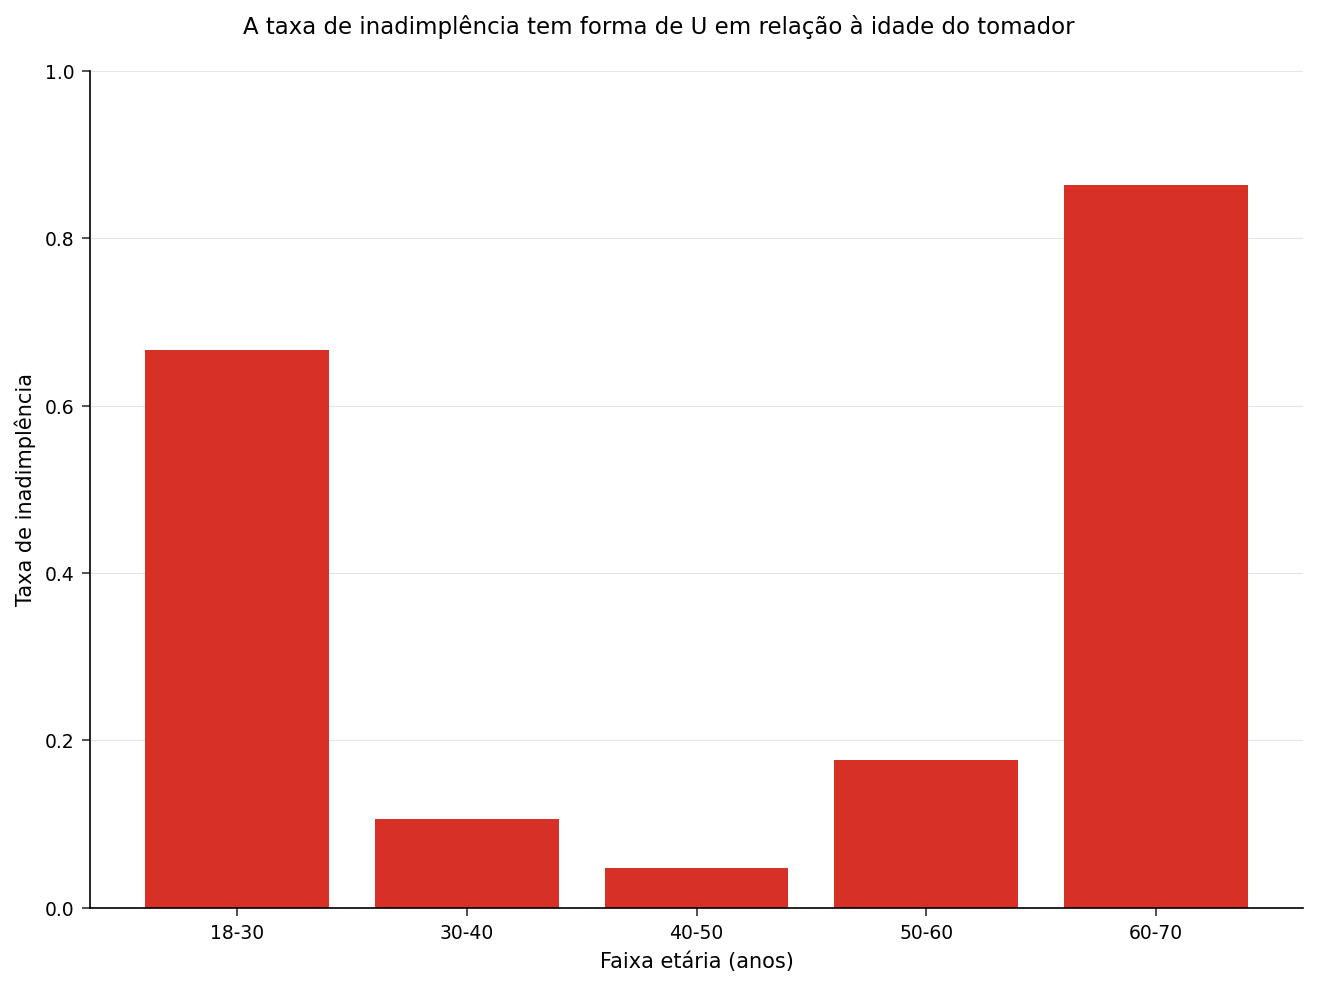

In [4]:
ODS GRAPHICS ON;

PROCEDIMENTO SGPLOT DADOS=age_rate noautolegend;
   TÍTULO "A taxa de inadimplência tem forma de U em relação à idade do tomador";
   VBAR age_band / RESPONSE=def_rate fillattrs=(color=cxd73027);
   YAXIS RÓTULO="Taxa de inadimplência" VALUES=(0 ATÉ 1 POR 0.2) grid;
   XAXIS RÓTULO="Faixa etária (anos)";
EXECUTAR;

TÍTULO;
ODS GRAPHICS OFF;

### O risco cresce com a alavancagem

As faixas de dívida-renda tendem para cima — os tomadores mais alavancados ficam inadimplentes com mais frequência — de forma consistente com a suavização dominante de DTI no modelo. As faixas intermediárias são ruidosas neste tamanho de amostra, ressaltando por que a spline ajustada é um guia mais estável do que qualquer corte único traçado à mão.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=dti_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


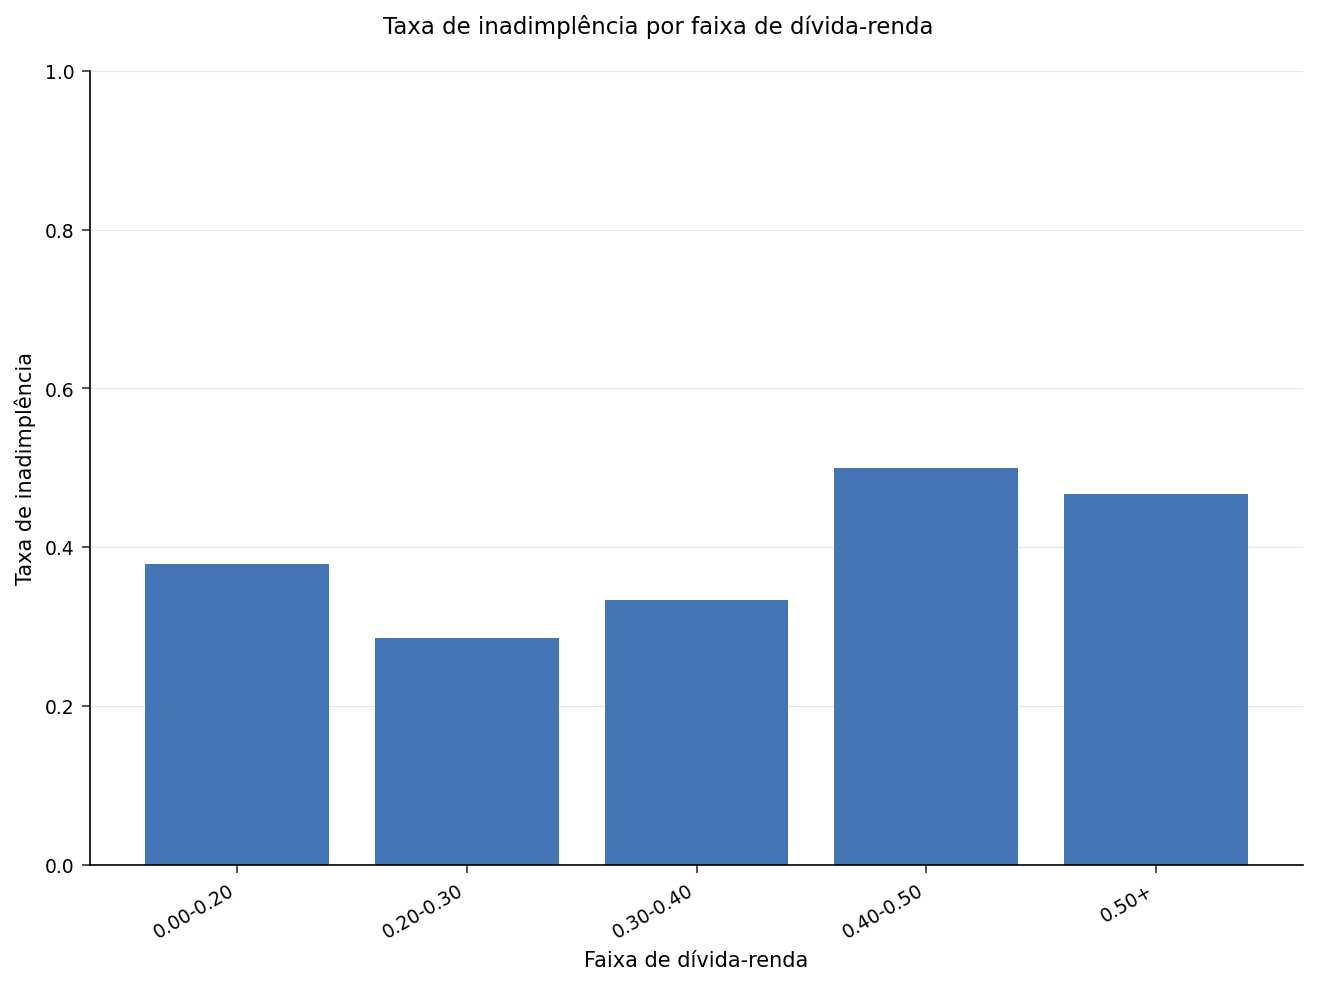

In [5]:
ODS GRAPHICS ON;

PROCEDIMENTO SGPLOT DADOS=dti_rate noautolegend;
   TÍTULO "Taxa de inadimplência por faixa de dívida-renda";
   VBAR dti_band / RESPONSE=def_rate fillattrs=(color=cx4575b4);
   YAXIS RÓTULO="Taxa de inadimplência" VALUES=(0 ATÉ 1 POR 0.2) grid;
   XAXIS RÓTULO="Faixa de dívida-renda";
EXECUTAR;

TÍTULO;
ODS GRAPHICS OFF;

## Interpretando os resultados

O `PROC GAM` recuperou a estrutura não linear que embutimos na carteira sintética sem qualquer discretização manual ou termos polinomiais:

- **Ajuste geral forte** - o modelo aditivo com splines reduz a deviância de 133,75 para 61,69 (uma redução de 72,06) para um AIC do modelo de 81,69, em uma carteira com taxa base de inadimplência de 39%.
- **A alavancagem domina** - a suavização de dívida-renda carrega o maior coeficiente (4,34) dos três termos, sinalizando o DTI como o principal condutor do log-odds ajustado.
- **Curvatura na idade** - discretizar o desfecho bruto confirma um U de manual: 66,7% de inadimplência na faixa abaixo de 30 anos, um vale de 4,8% em 40-50 anos e 86,4% na faixa de 60 anos ou mais — a forma que uma spline cúbica captura naturalmente, mas que um único termo linear de idade deixaria passar por completo.
- **Honesto quanto ao ruído** - com 100 empréstimos, as taxas de dívida-renda por faixa oscilam, o que é precisamente o argumento a favor de uma estimativa suavizada em vez de um corte rígido escolhido à mão.

**Por que isso importa para o setor bancário:** splines aditivas dão à equipe de risco uma maneira rápida e automática de detectar onde uma relação é genuinamente não linear antes de se comprometer com um scorecard de produção. As suavizações ajustadas são diretamente interpretáveis como curvas de risco — um prêmio de idade para jovens e idosos, uma rampa de alavancagem — e a deviância e o AIC quantificam o quanto essa flexibilidade vale em comparação com um modelo linear plano.